In [1]:
import time
import os
import numpy as np
import sys
sys.path.append(os.path.dirname(os.getcwd()))
from modules import CHIP
from util import *

In [2]:
chip=CHIP(local_ip="192.168.1.15",remote_ip="192.168.1.10",remote_port=7,debug=1,max_packet_size=2**23,init=True)
chip.set_device_cfg(deviceType=0,IsNew32=True,IsRERAM512=False)
chip.adc.set_gap(adc_cs_gap=100,adc_first_gap=500,adc_last_gap=20)
chip.adc.set_gain_resistor(big_resistance=22e-3,small_resistance=200)
chip.adc.set_sample_times(adc_sample_times=32)
chip.clk_manager.set_cyc(delay1=10,delay2=10,delay3=50)

Failed to connect: [WinError 10049] 在其上下文中，该请求的地址无效。
完整字节码: 55aa010900000fff
完整字节码: 55aa010100000080
完整字节码: 55aa010100000100
完整字节码: 55aa010d00000001
完整字节码: 55aa010e00000001
模式: 1
	帧头:               	字节码: 55 aa 01
	指令: flt           	字节码: 09 00 00 0f ff
模式: 1
	帧头:               	字节码: 55 aa 01
	指令: fast_command_1	字节码: 01 00 00 00 80
模式: 1
	帧头:               	字节码: 55 aa 01
	指令: fast_command_1	字节码: 01 00 00 01 00
模式: 1
	帧头:               	字节码: 55 aa 01
	指令: cim_ss        	字节码: 0d 00 00 00 01
模式: 1
	帧头:               	字节码: 55 aa 01
	指令: ser_para_sel  	字节码: 0e 00 00 00 01

Failed to send message:
完整字节码: 55aa010b00000001
模式: 1
	帧头:          	字节码: 55 aa 01
	指令: cim_reset	字节码: 0b 00 00 00 01

Failed to send message:
完整字节码: 55aa01030000a200
完整字节码: 55aa01040000a200
完整字节码: 55aa01050000a200
完整字节码: 55aa01060000a200
完整字节码: 55aa01320000a200
完整字节码: 55aa01330000a200
完整字节码: 55aa01340000a200
完整字节码: 55aa01350000a200
完整字节码: 55aa0101000f001e
模式: 1
	帧头:               	字节码: 55 aa 01
	指令: adc0_in       	字节码: 03

In [ ]:
chip.ps.receive_packet(256*256*64)

In [99]:
start = time.perf_counter()
crossbar = np.ones((256,256))
v,c1,r = chip.read4(crossbar=crossbar,row_index=[i for i in range(1)],col_index=[i for i in range(0,4)],read_voltage=0.1,tg=5,gain=1,sub_base=False,from_row=True,split_type=6,row_type=0,col_type=0)
end = time.perf_counter()
elapsed_time = end - start
print(f"代码执行耗时: {elapsed_time:.6f} 秒")

完整字节码: 55aa011000000001
模式: 1
	帧头:     	字节码: 55 aa 01
	指令: gain	字节码: 10 00 00 00 01

完整字节码: 55aa0400000004190100001a0000001b0100000b000000
模式: 4
	帧头:               	字节码: 55 aa 04
	指令: pl_ram_addr   	字节码: 00 00
	指令: pl_data_length	字节码: 00 04
	指令: pl_row_ctrli  	字节码: 19 01 00 00
	指令: pl_col_ctrli  	字节码: 1a 00 00 00
	指令: pl_row_col_swi	字节码: 1b 01 00 00
	指令: pl_exit       	字节码: 0b 00 00 00

完整字节码: 55aa010100008000
模式: 1
	帧头:               	字节码: 55 aa 01
	指令: fast_command_1	字节码: 01 00 00 80 00

完整字节码: 55aa050000000400000000ffffffff0000000100000002
模式: 5
	帧头:               	字节码: 55 aa 05
	指令: pl_ram_addr   	字节码: 00 00
	指令: pl_data_length	字节码: 00 04
	指令: pl_data       	字节码: 00 00 00 00
	指令: pl_data       	字节码: ff ff ff ff
	指令: pl_data       	字节码: 00 00 00 01
	指令: pl_data       	字节码: 00 00 00 02

完整字节码: 55aa040000000f030805100306fff00100ff00010001020200ff00020001020400000002000103040000010200ff00020010020400000202001003040000030b000000
模式: 4
	帧头:                  	字节码: 55 aa 04
	指令: pl_ram_add

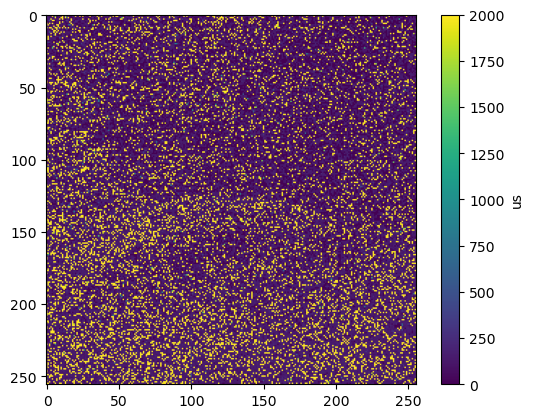

In [8]:
plot_cond(c1,vmax=2000)

In [3]:
ps_ddr_pos_start = 0xA100000 // 0x20  # 至少从这个ddr地址之后存放
ps_ddr_pos = ps_ddr_pos_start

In [6]:
start = time.perf_counter()
chip.ps.set_time_out(1)
crossbar = np.zeros((1,256))
for i in range(1):
    crossbar[i,i] =1
output,v,c2,r,ps_ddr_pos = chip.inference6(crossbar,row_index=[i for i in range(256)],col_index=[i for i in range(0,4)],read_voltage=0.1,tg=5,gain=1,sub_base=True,from_row=True,split_type=3,ps_ddr_pos=ps_ddr_pos)

end = time.perf_counter()
elapsed_time = end - start
print(f"代码执行耗时: {elapsed_time:.6f} 秒")

完整字节码: 55aa090050800000000004190100001a0000001b0100000b000000
模式: 9
	帧头:               	字节码: 55 aa 09
	指令: ps_ddr_addr   	字节码: 00 50 80 00
	指令: ps_data_length	字节码: 00 00 00 04
	指令: pl_row_ctrli  	字节码: 19 01 00 00
	指令: pl_col_ctrli  	字节码: 1a 00 00 00
	指令: pl_row_col_swi	字节码: 1b 01 00 00
	指令: pl_exit       	字节码: 0b 00 00 00

Failed to send message:
完整字节码: 55aa0a005080021000000001
模式: 10
	帧头:            	字节码: 55 aa 0a
	指令: ps_ddr_addr	字节码: 00 50 80 02
	指令: gain       	字节码: 10 00 00 00 01

Failed to send message:
完整字节码: 55aa090050800300000003030805100306fff00b000000
模式: 9
	帧头:               	字节码: 55 aa 09
	指令: ps_ddr_addr   	字节码: 00 50 80 03
	指令: ps_data_length	字节码: 00 00 00 03
	指令: pl_dac_v      	字节码: 03 08 05 10
	指令: pl_dac_v      	字节码: 03 06 ff f0
	指令: pl_exit       	字节码: 0b 00 00 00

Failed to send message:
完整字节码: 55aa0e005080050000003000000000000000000000000000000000000000000000000000000000000000010000000000000000000000000000000000000000000000000000000000000004000000000000000000000000

ValueError: cannot reshape array of size 0 into shape (8,32)

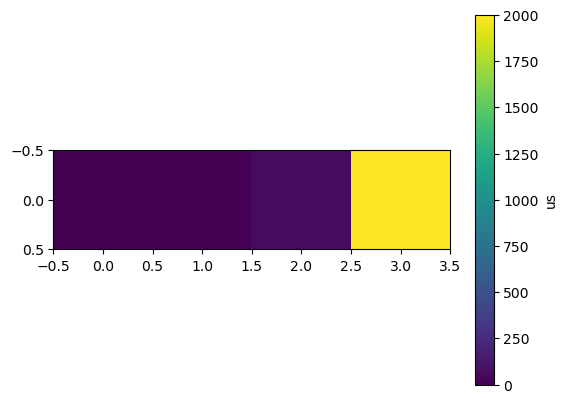

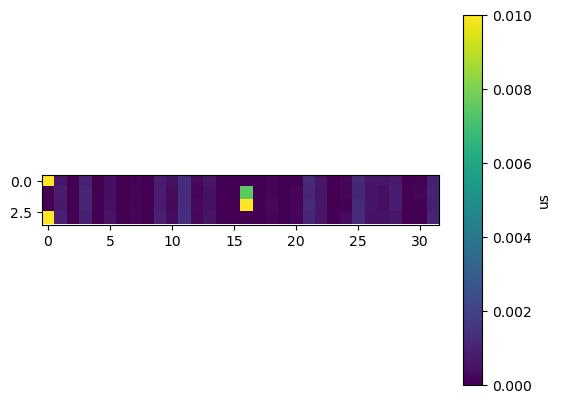

In [103]:
plot_cond(c2,vmax=2000)
plot_cond(output[:256,:],vmax=0.01)

In [18]:
print(chip.setting.TIA_index_map(num=0,col=True))
print(chip.setting.tia_to_num([5],row=F))

16
[81, 83, 85, 87, 89, 91, 93, 95]


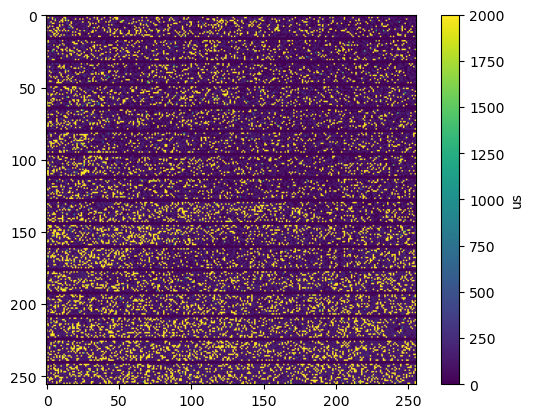

In [91]:
plot_cond(c2.T,vmax=2000)

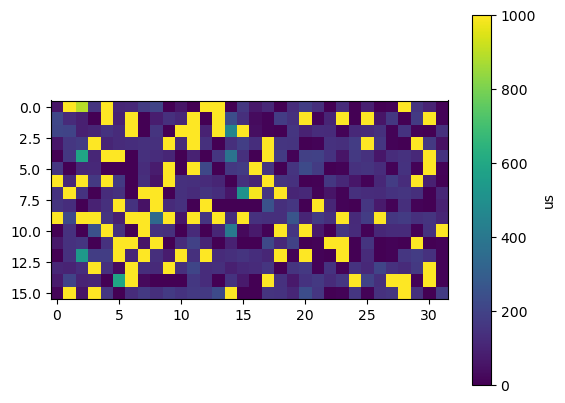

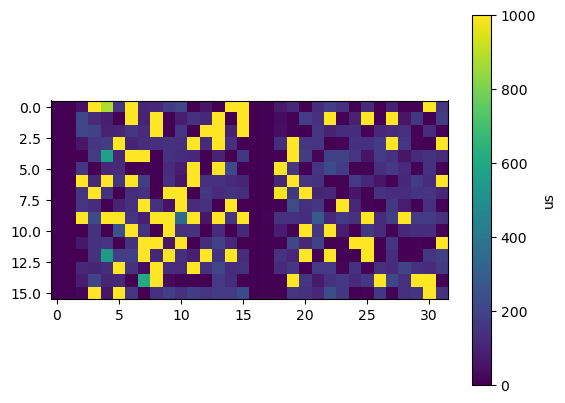

In [10]:
plot_cond(c1[:16,:32],vmax=1000)
plot_cond(c2[:16,:32],vmax=1000)

# plot_cond(c1[2:14,32:64],vmax=1000)
# plot_cond(c2.T[:12,32:64],vmax=1000)

# plot_cond(c1[2:14,:]-c2.T[:12,:],vmax=50)

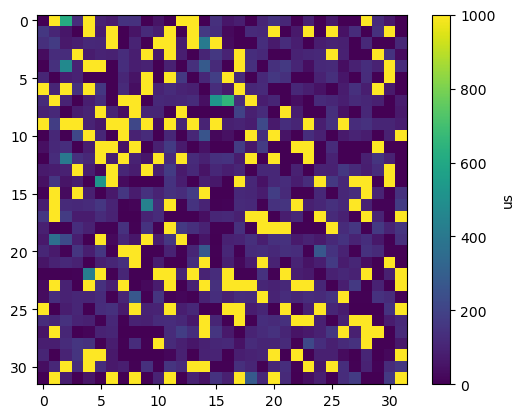

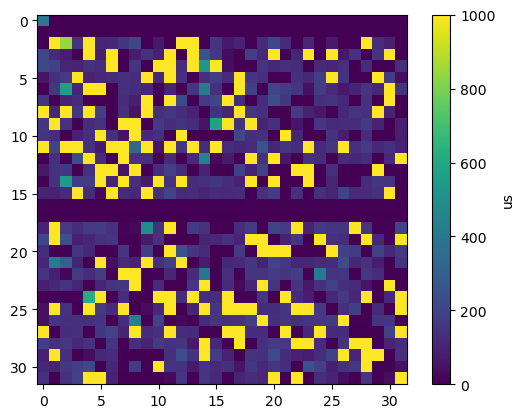

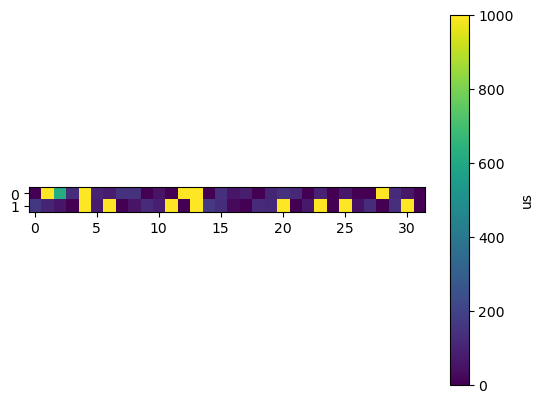

In [71]:
plot_cond(c1[0:32,:32],vmax=1000)
plot_cond(c2.T[:32,:32],vmax=1000)
plot_cond(c1[:2,:32],vmax=1000)
# plot_cond(c1[2:14,:]-c2.T[:12,:],vmax=50)
# plot_cond(output[:20,:],vmax=0.3)
# print(np.sum(output[:16,:]>0.01))

In [ ]:
factor = np.zeros((256,256))

for m in range(256):
    a = c1[m,:]
    b = 1000000
    pos = 0
    for i in range(256):
        tmp = np.abs(np.sum(a-c2.T[i,:]))
        if tmp<b:
            b = tmp
            pos = i

    print(m,"-->",pos)


In [ ]:
plot_cond(c1[:10,:]-c2.T[2:12,:],vmax=2000,vmin=-100)

In [ ]:
plot_cond(c1-c2,vmax=1000,vmin=-100)

In [ ]:
ps_ddr_pos_start = ps_ddr_pos
start = time.perf_counter()


data_all = []
ps_ddr_pos,data=chip.read5(crossbar=None,row_index=[i for i in range(256)],col_index=[i for i in range(0,256,1)],read_voltage=0.1,tg=5,gain=1,sub_base=True,from_row=True,
                split_type=7,row_type=0,col_type=0,ps_ddr_pos=ps_ddr_pos)
data_all.append(data)
chip.ps.set_time_out(20)
ps_ddr_pos = chip.send_ps_run(flag=2,ps_ddr_pos_start=ps_ddr_pos_start,ps_ddr_pos=ps_ddr_pos)

for i in range(len(data_all)):
    data_item = data_all[i]

    v, c, r = chip.get_read5(*data_item)

chip.ps.receive_packet_check(bytes_num=4,message_check="cc550000")

end = time.perf_counter()
elapsed_time = end - start
print(f"代码执行耗时: {elapsed_time:.6f} 秒")

In [ ]:
chip.ps.receive_packet(400096)

In [ ]:
plot_cond(c,vmax=1000)

In [ ]:
chip.ps.receive_packet(4096)

In [ ]:
def _numToBank_Index(num:int) -> tuple[int,int]:
        """
            Args:
                num: 行/列号, 从0开始

            Returns:
                tuple: (bank, index) 其中 bank[0:8] 和 index[0:31] 坐标从0开始
        """
        num += 1
        # 先判断奇数偶数
        if num&1:
            index_base,index_offset = 64,1
            bank_base = 0
        else:
            index_base,index_offset = 64,2
            bank_base = 4

        bank_offset = int((num-index_offset)/index_base)
        bank = bank_base + bank_offset
        index = int((num - index_offset - bank_offset * index_base) / 2)
        print(bank, index)

In [ ]:
print(_numToBank_Index(63))

### 准备输入数据并下放

In [ ]:
# 首次运行
# start_time = time.perf_counter()
ps_ddr_pos_start = 0xA100000 // 0x20  # 至少从这个ddr地址之后存放
ps_ddr_pos = ps_ddr_pos_start

In [ ]:
# 输入图片准备，从列输入
BATCH_SIZE = 1000  # 10000
test_loss_ = 0
correct = 0
test_samples = 0
test_loader = get_mnist_cropped(BATCH_SIZE, train=False, val=True)[0]
test_acc = []
output_row_num = 1
input_col_num = 196

test_criterion = nn.CrossEntropyLoss(reduction='sum')

max_samples = 1000  # 仅测试的最大样本数

b_col, b_row = [i for i in range(0, 128)], [0]

data_all = []

# 在数据收集阶段，为每个样本记录必要的元数据
sample_metadata = []  # 记录每个样本的元数据
current_sample_idx = 0

# 准备数据
for idx, (data, label) in enumerate(test_loader):
    if test_samples >= max_samples:
        break

    test_samples += data.size(0)
    data = data.reshape(data.shape[0], 196, 1)  # reshape为[BATCH_SIZE, H*W, 1]
    data_int = data.byte()  # 转换为 uint8 类型 [BATCH_SIZE, H*W, 1]
    binary_bits = []

    for i in range(7, -1, -1):  # 从第7位（最高位）到第0位（最低位）
        bit = (data_int >> i) & 1  # 提取第i位 [BATCH_SIZE, H*W, 1]
        binary_bits.append(bit)
    data_binary = torch.cat(binary_bits, dim=-1)  # 形状变为 [BATCH_SIZE, H*W, 8]
    for n in range(data_binary.shape[0]):
        # 为每个样本记录开始位置和位流数量
        sample_start_idx = len(data_all)
        bit_stream_count = data_binary.shape[2]  # 8个位流
        
        sample_metadata.append({
            'batch_idx': idx,
            'sample_idx': current_sample_idx,
            'data_start': sample_start_idx,
            'bit_stream_count': bit_stream_count,
            'label': label[n] if label is not None else None
            # 后续还要添加8个位的num_col_activated list
        })
        current_sample_idx += 1
        
        for k in range(data_binary.shape[2]):
            input_bit_stream = data_binary[n, :, k]  # 单次的位流输入
            input_col, output_row = [x for x, mask in zip(b_col, input_bit_stream) if mask == 1], b_row  # 这里input_bit_stream按顺序开启/关闭乱序的列号，但权重按照相同顺序提前映射好了，故是一致的

            # v_base,_,_ = chip.read4(crossbar=None,row_index=output_row,col_index=input_col,read_voltage=0,tg=5,gain=3,sub_base=False,from_row=False,split_type=3,row_type=0,col_type=0)
            # v,_,_ = chip.read4(crossbar=None,row_index=output_row,col_index=input_col,read_voltage=0.1,tg=5,gain=3,sub_base=False,from_row=False,split_type=3,row_type=0,col_type=0)
            # c = chip.voltage_to_cond(voltage = v - v_base)
            
            ps_ddr_pos,data=chip.read5(crossbar=None,row_index=output_row,col_index=input_col,read_voltage=0.1,tg=5,gain=3,sub_base=True,from_row=False,
                        split_type=3,row_type=0,col_type=0,ps_ddr_pos=ps_ddr_pos)
            data_all.append(data)


In [ ]:
# 只测试DMA传输+执行指令时间+数据返回
start_time = time.perf_counter()

In [ ]:
# 开始执行指令
ps_ddr_pos = chip.send_ps_run(flag=2,ps_ddr_pos_start=ps_ddr_pos_start,ps_ddr_pos=ps_ddr_pos)

overall_output = []
current_data_idx = 0
current_batch_idx = -1
batch_output = []  # 当前batch的输出列表

for sample_meta in sample_metadata:
    # 如果切换到新的batch，保存上一个batch的输出
    if sample_meta['batch_idx'] != current_batch_idx:
        if batch_output:  # 如果batch_output不为空，添加到overall_output
            overall_output.extend(batch_output)
        batch_output = []  # 重置为新的batch
        current_batch_idx = sample_meta['batch_idx']
    
    sample_output = np.zeros(output_row_num)
    
    # 处理当前样本的所有位流
    for bit_idx in range(sample_meta['bit_stream_count']):
        if current_data_idx < len(data_all):
            data_item = data_all[current_data_idx]

            v, c, r = chip.get_read5(*data_item)

            current_data_idx += 1
            
            partial_output = c[b_row]
            
            bit_weight = 2 ** (7 - bit_idx)  # 最高位权重128，最低位权重1
            sample_output += partial_output * bit_weight
    
    # 将当前样本输出添加到batch_output中
    batch_output.append(sample_output)
# 添加最后一个batch的输出
if batch_output:
    overall_output.extend(batch_output)
# 转换为tensor便于后续计算
overall_output = torch.tensor(np.array(overall_output), dtype=torch.float32)

print(f"处理完成: 总共{len(overall_output)}个样本，{len(sample_metadata)}个元数据记录")

chip.ps.receive_packet_check(bytes_num=4,message_check="cc550000")

end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"DDR方法总用时: {elapsed_time:.6f} seconds")

In [ ]:
print(len(data_all))

In [ ]:
print(current_data_idx)

In [ ]:
print(hex(ps_ddr_pos))